# Análisis de conectividad en la red del CENTIC con BFS

Este notebook modela la red del CENTIC como un grafo no dirigido y aplica BFS para determinar si existe una ruta válida entre un dispositivo de origen y el servidor central bajo restricciones de seguridad, ancho de banda y latencia.

In [ ]:
# Librerías base para construir el grafo, recorrerlo y resumir resultados.
import random
from collections import deque
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Modelo del grafo

Sea $G=(V,E)$ un grafo no dirigido. Cada vértice representa un dispositivo de red o un equipo final. Cada arista representa una conexión física y tiene atributos $(s, b, l)$, donde $s$ es la seguridad, $b$ es el ancho de banda (Mbps) y $l$ es la latencia (ms).

La seguridad $s$ se modela en una escala ordinal de 1 a 5 con criterios operativos:

- 1: enlace sin segmentación ni cifrado; acceso abierto.
- 2: segmentación básica (VLAN), sin controles fuertes.
- 3: segmentación y autenticación básica, como 802.1X o credenciales, con monitoreo estándar.
- 4: segmentación y autenticación fuerte, con IDS/IPS o políticas estrictas.
- 5: enlace crítico con controles reforzados, como segmentación estricta, monitoreo continuo y acceso mínimo.

Por tanto, $s_{min}$ representa la seguridad mínima requerida en un escenario.

Una arista es válida si cumple $s \ge s_{min}$, $b \ge b_{min}$ y $l \le l_{max}$. El problema se reduce a encontrar un camino en el subgrafo formado por las aristas válidas.

In [ ]:
# Fijamos la semilla para que la construcción y las figuras sean reproducibles.
random.seed(42)

## Escenarios y umbrales

Se consideran escenarios de operación con distintos umbrales:

- Normal: requisitos corporativos estándar sobre fibra.
- Seguridad alta: umbrales más estrictos para enlaces sensibles.
- Crítico: exige $s=5$ en todos los criterios, pensado para el servidor central o cámaras.
- Congestión: tolera mayor latencia y menor ancho de banda, con una exigencia de seguridad más flexible.

In [ ]:
# Umbrales mínimos por escenario: seguridad, ancho de banda y latencia.
SCENARIOS = {
    "normal": {"s_min": 3, "b_min": 100, "l_max": 30},
    "seguridad_alta": {"s_min": 4, "b_min": 200, "l_max": 20},
    "critico": {"s_min": 5, "b_min": 300, "l_max": 15},
    "congestion": {"s_min": 2, "b_min": 50, "l_max": 50},
}

## Construcción del grafo

Se modelan 4 pisos, cada uno con 6 aulas: 5 normales con 15 PCs y 1 aula grande con 30 PCs. Cada aula tiene un PC central, una cámara y un router Wi-Fi. Además, cada piso cuenta con un puesto de recepción, una impresora y cámaras en el pasillo.

También se incluye un bloque administrativo y un cuarto de vigilancia. Todos los componentes se conectan al servidor central a través de un core switch.

In [ ]:
def add_edge(G, u, v, security, bandwidth, latency):
    # Guardamos en cada arista los atributos que luego filtrará BFS.
    G.add_edge(u, v, security=security, bandwidth=bandwidth, latency=latency)


def build_centic_graph():
    # Se construye un grafo no dirigido con el servidor central como nodo raíz.
    G = nx.Graph()

    server = "server_central"
    core_switch = "core_switch"
    G.add_node(server, type="server")
    G.add_node(core_switch, type="core_switch")
    add_edge(G, server, core_switch, security=5, bandwidth=10000, latency=2)

    # Bloque administrativo y vigilancia, conectados al core con enlaces robustos.
    admin_switch = "admin_switch"
    surveillance_pc = "surveillance_pc"
    G.add_node(admin_switch, type="admin_switch")
    G.add_node(surveillance_pc, type="surveillance")
    add_edge(G, core_switch, admin_switch, security=5, bandwidth=1000, latency=5)
    add_edge(G, core_switch, surveillance_pc, security=5, bandwidth=1000, latency=5)

    admin_pcs = []
    for i in range(1, 6):
        pc = f"admin_pc_{i}"
        admin_pcs.append(pc)
        G.add_node(pc, type="admin_pc")
        add_edge(G, admin_switch, pc, security=5, bandwidth=500, latency=8)
    admin_printers = []
    for i in range(1, 3):
        pr = f"admin_printer_{i}"
        admin_printers.append(pr)
        G.add_node(pr, type="admin_printer")
        add_edge(G, admin_switch, pr, security=5, bandwidth=300, latency=10)

    # Cada piso replica la misma estructura básica para mantener el modelo uniforme.
    for floor in range(1, 5):
        floor_switch = f"floor{floor}_switch"
        receptionist_pc = f"floor{floor}_reception_pc"
        receptionist_printer = f"floor{floor}_reception_printer"

        G.add_node(floor_switch, type="floor_switch", floor=floor)
        G.add_node(receptionist_pc, type="reception_pc", floor=floor)
        G.add_node(receptionist_printer, type="reception_printer", floor=floor)

        add_edge(G, core_switch, floor_switch, security=5, bandwidth=1000, latency=5)
        add_edge(G, floor_switch, receptionist_pc, security=5, bandwidth=500, latency=8)
        add_edge(G, floor_switch, receptionist_printer, security=5, bandwidth=300, latency=10)

        # Cámaras de pasillo: enlaces moderados en seguridad y ancho de banda.
        for c in range(1, 4):
            cam = f"floor{floor}_corridor_cam_{c}"
            G.add_node(cam, type="camera", floor=floor)
            add_edge(G, floor_switch, cam, security=4, bandwidth=200, latency=15)

        # Aulas con switch propio, PC central, cámara, wifi y PCs de trabajo.
        for room in range(1, 7):
            room_tag = f"floor{floor}_room{room}"
            central_pc = f"{room_tag}_central_pc"
            cam = f"{room_tag}_cam"
            wifi_router = f"{room_tag}_wifi"
            room_switch = f"{room_tag}_switch"
            G.add_node(central_pc, type="room_central", floor=floor)
            G.add_node(cam, type="camera", floor=floor)
            G.add_node(wifi_router, type="wifi", floor=floor)
            G.add_node(room_switch, type="room_switch", floor=floor)

            add_edge(G, floor_switch, room_switch, security=4, bandwidth=1000, latency=8)
            add_edge(G, room_switch, central_pc, security=5, bandwidth=1000, latency=8)
            add_edge(G, room_switch, cam, security=4, bandwidth=200, latency=15)
            add_edge(G, room_switch, wifi_router, security=2, bandwidth=100, latency=25)

            # El aula 6 es más grande, por eso tiene más equipos.
            pc_count = 30 if room == 6 else 15
            for i in range(1, pc_count + 1):
                pc = f"{room_tag}_pc_{i}"
                G.add_node(pc, type="pc", floor=floor)
                add_edge(G, room_switch, pc, security=3, bandwidth=100, latency=20)

    return G

G = build_centic_graph()
len(G.nodes), len(G.edges)

(551, 550)

## BFS con filtrado de aristas

Se implementa un BFS propio. La complejidad temporal es $O(|V|+|E|)$ y la espacial es $O(|V|)$. El filtrado de aristas se aplica durante la expansión de vecinos, de modo que solo se recorren enlaces que cumplen los umbrales definidos.

In [ ]:
def edge_is_valid(data, s_min, b_min, l_max):
    # La arista solo se considera si cumple los tres umbrales al mismo tiempo.
    return (data["security"] >= s_min and
            data["bandwidth"] >= b_min and
            data["latency"] <= l_max)


def bfs_valid_path(G, source, target, s_min, b_min, l_max):
    # BFS clásico, pero expandiendo solo vecinos unidos por aristas válidas.
    visited = set([source])
    parent = {source: None}
    q = deque([source])

    while q:
        u = q.popleft()
        if u == target:
            break
        for v in G.neighbors(u):
            if v in visited:
                continue
            data = G.get_edge_data(u, v)
            if not edge_is_valid(data, s_min, b_min, l_max):
                continue
            visited.add(v)
            parent[v] = u
            q.append(v)

    if target not in parent:
        return None, len(visited)

    # Reconstruimos la ruta desde el destino hacia el origen.
    path = []
    cur = target
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path, len(visited)

## Experimentos

Se prueban rutas desde distintos orígenes hacia el servidor central en cada escenario.

In [ ]:
# Puntos de origen representativos para evaluar conectividad hacia el servidor.
server = "server_central"
origins = {
    "pc_aula": "floor2_room3_pc_5",
    "pc_central_aula": "floor1_room6_central_pc",
    "admin_pc": "admin_pc_2",
    "surveillance": "surveillance_pc",
}

results = []
for scen, th in SCENARIOS.items():
    # Probamos cada origen bajo los umbrales del escenario actual.
    for label, src in origins.items():
        path, visited = bfs_valid_path(G, src, server, **th)
        results.append({
            "scenario": scen,
            "origin": label,
            "reachable": path is not None,
            "path_length": None if path is None else len(path) - 1,
            "visited": visited,
        })

df_results = pd.DataFrame(results)
df_results

,scenario,origin,reachable,path_length,visited
0,normal,pc_aula,True,4.0,136
1,normal,pc_central_aula,True,4.0,136
2,normal,admin_pc,True,3.0,15
3,normal,surveillance,True,2.0,8
4,seguridad_alta,pc_aula,False,NaN,1
5,seguridad_alta,pc_central_aula,True,4.0,31
6,seguridad_alta,admin_pc,True,3.0,15
7,seguridad_alta,surveillance,True,2.0,8
8,critico,pc_aula,False,NaN,1
9,critico,pc_central_aula,False,NaN,2


## Visualización de topología

Se grafica un subgrafo representativo de un piso para mantener la legibilidad.

/tmp/ipykernel_44738/1101408676.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


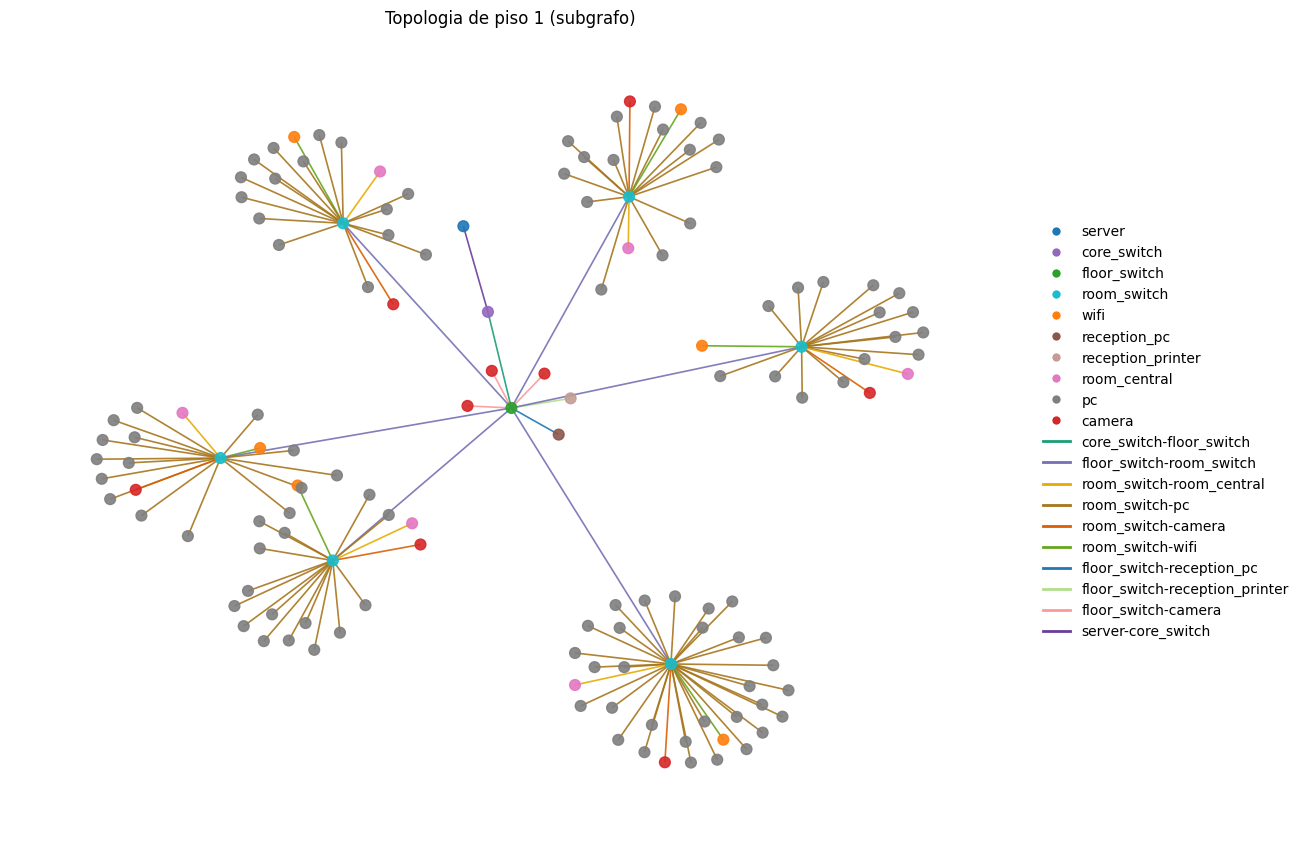

In [ ]:
# Tomamos un subgrafo pequeño para que la visualización siga siendo legible.
nodes_floor1 = [n for n, d in G.nodes(data=True) if d.get("floor") == 1]
nodes_core = ["server_central", "core_switch", "floor1_switch"]
sub_nodes = set(nodes_floor1 + nodes_core)
H = G.subgraph(sub_nodes).copy()

# Colores por tipo de nodo para distinguir capas de la red.
node_colors_by_type = {
    "server": "#1f77b4",
    "core_switch": "#9467bd",
    "floor_switch": "#2ca02c",
    "room_switch": "#17becf",
    "wifi": "#ff7f0e",
    "reception_pc": "#8c564b",
    "reception_printer": "#c49c94",
    "room_central": "#e377c2",
    "pc": "#7f7f7f",
    "camera": "#d62728",
}

# Colores de aristas por relación estructural principal.
edge_colors_by_pair = {
    ("core_switch", "floor_switch"): "#1b9e77",
    ("floor_switch", "room_switch"): "#7570b3",
    ("room_switch", "room_central"): "#e6ab02",
    ("room_switch", "pc"): "#a6761d",
    ("room_switch", "camera"): "#d95f02",
    ("room_switch", "wifi"): "#66a61e",
    ("floor_switch", "reception_pc"): "#1f78b4",
    ("floor_switch", "reception_printer"): "#b2df8a",
    ("floor_switch", "camera"): "#fb9a99",
    ("server", "core_switch"): "#6a3d9a",
}

node_colors = []
for n in H.nodes():
    n_type = H.nodes[n].get("type")
    node_colors.append(node_colors_by_type.get(n_type, "#cccccc"))

edge_colors = []
for u, v in H.edges():
    u_type = H.nodes[u].get("type")
    v_type = H.nodes[v].get("type")
    pair = (u_type, v_type)
    rev_pair = (v_type, u_type)
    edge_colors.append(edge_colors_by_pair.get(pair, edge_colors_by_pair.get(rev_pair, "#bbbbbb")))

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, seed=42, k=0.2)
nx.draw(
    H, pos, node_size=60, with_labels=False, alpha=0.9,
    node_color=node_colors, edge_color=edge_colors, width=1.2
)
plt.title("Topologia de piso 1 (subgrafo)")

from matplotlib.lines import Line2D

# Leyendas separadas para nodos y enlaces.
node_legend = [
    Line2D([0], [0], marker="o", color="w", label=label,
           markerfacecolor=color, markersize=7)
    for label, color in node_colors_by_type.items()
]
edge_legend = [
    Line2D([0], [0], color=color, lw=2, label=f"{a}-{b}")
    for (a, b), color in edge_colors_by_pair.items()
]

plt.legend(handles=node_legend + edge_legend, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

## Tablas comparativas

Se comparan los escenarios por alcanzabilidad y longitud promedio de la ruta.

In [ ]:
# Resumimos el comportamiento de BFS por escenario.
summary = (
    df_results.groupby("scenario")
    .agg(reachable_rate=("reachable", "mean"),
         avg_path_length=("path_length", "mean"),
         avg_visited=("visited", "mean"))
    .reset_index()
)
summary

,scenario,reachable_rate,avg_path_length,avg_visited
0,congestion,1.00,3.25,76.75
1,critico,0.50,2.50,6.50
2,normal,1.00,3.25,73.75
3,seguridad_alta,0.75,3.00,13.75


## Comparación gráfica

Se muestra un gráfico de barras con el porcentaje de orígenes alcanzables por escenario.

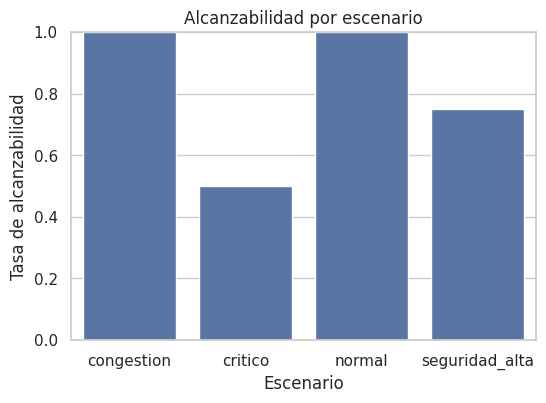

In [ ]:
# Barras simples para comparar la proporción de orígenes alcanzables.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(data=summary, x="scenario", y="reachable_rate")
plt.ylim(0, 1)
plt.title("Alcanzabilidad por escenario")
plt.ylabel("Tasa de alcanzabilidad")
plt.xlabel("Escenario")
plt.show()

## Conclusiones

El modelo muestra que la conectividad hacia el servidor central depende de las restricciones aplicadas sobre las aristas. En escenarios de alta seguridad, algunos orígenes pueden perder alcanzabilidad por enlaces con seguridad insuficiente, mientras que en congestión la alcanzabilidad se mantiene, aunque con posibles rutas más largas. BFS permite verificar alcanzabilidad y estimar el número de saltos con complejidad lineal respecto al tamaño del grafo.

## Trabajo futuro

Se propone incorporar políticas de acceso dirigidas, usando un grafo dirigido, y niveles de prioridad por tipo de dispositivo. También se puede calibrar el modelo con datos reales de tráfico del CENTIC y evaluar escenarios de falla en switches o enlaces críticos para estudiar la resiliencia.